In [71]:
import zarr
import s3fs
import numpy as np
from src.train import *

from pprint import pprint

# SageMaker
import sagemaker
from sagemaker.feature_store.feature_group import FeatureGroup
from sagemaker.workflow.pipeline import Pipeline
from sagemaker.workflow.pipeline_context import PipelineSession
from sagemaker.workflow.steps import ProcessingStep, TrainingStep, CacheConfig
from sagemaker.workflow.parameters import (
    ParameterInteger,
    ParameterString,
    ParameterFloat,
)
from sagemaker.processing import ScriptProcessor, ProcessingInput, ProcessingOutput
from sagemaker.workflow.properties import PropertyFile
from sagemaker.pytorch.estimator import PyTorch
from sagemaker.inputs import TrainingInput
from sagemaker.model import Model
from sagemaker.model_metrics import MetricsSource, ModelMetrics
from sagemaker.inputs import CreateModelInput
from sagemaker.workflow.model_step import ModelStep
from sagemaker.transformer import Transformer
from sagemaker.inputs import TransformInput
from sagemaker.workflow.steps import TransformStep
from sagemaker.workflow.fail_step import FailStep
from sagemaker.workflow.functions import Join
from sagemaker.workflow.conditions import ConditionLessThanOrEqualTo
from sagemaker.workflow.condition_step import ConditionStep
from sagemaker.workflow.functions import JsonGet

In [72]:
%store -r

In [73]:
# Location constants
ZARR_REF = f"{s3_project_prefix}/store"
TRAIN_REF = "train_indices.npy"
VAL_REF = "val_indices.npy"
INDICES_REF = f"{s3_project_prefix}/indices"

# Data Splitting

In [74]:
# Open the S3 filesystem
fs = s3fs.S3FileSystem()

# Open the zarr store
store = s3fs.S3Map(root=os.path.join(ZARR_REF, "data.zarr"), s3=fs, check=False)
n = zarr.open(store, mode='r')['inside_masks'].shape[0]
indices = np.arange(n)

# Setting seed for reproducibility
np.random.seed(39)
np.random.shuffle(indices)

split = int(n * 0.8)
train_idx = indices[:split]
val_idx   = indices[split:]

# Persist the split across runs
np.save(TRAIN_REF, train_idx)
np.save(VAL_REF,   val_idx)

# Push to S3
fs.put(TRAIN_REF, f"{INDICES_REF}/{TRAIN_REF}")
fs.put(VAL_REF, f"{INDICES_REF}/{VAL_REF}")

[None]

# Pipeline Parameters

In [75]:
# caching
cache_config = CacheConfig(enable_caching=True, expire_after="PT1H")

# Processing params
processing_instance_count = ParameterInteger(
    name="ProcessingInstanceCount", default_value=1
    )

processing_instance_type = ParameterString(
    name="ProcessingInstanceType", default_value="ml.g5.4xlarge"
    )

# Training Params
training_instance_count = ParameterInteger(
    name="TrainingInstanceCount", default_value=1
    )

training_instance_type = ParameterString(
    name="TrainingInstanceType", default_value="ml.g5.4xlarge"
    )

# Evaluation Params
eval_instance_count = ParameterInteger(
    name="EvalInstanceCount", default_value=1
    )

eval_instance_type = ParameterString(
    name="EvalInstanceType", default_value="ml.g5.xlarge"
    )

model_package_group_name = f"InteriorBoundsModelPackage"

model_approval_status = ParameterString(
    name="ModelApprovalStatus", default_value="Approved"
)

mse_threshold = ParameterFloat(name="MseThreshold", default_value=0.10)

In [76]:
model_path = f"{s3_project_prefix}/models/model_artifacts"

sagemaker_session = sagemaker.Session()
role = sagemaker.get_execution_role()
region = sagemaker_session._region_name
pipeline_session = PipelineSession()

# Training Step

In [77]:
pytorch_train = PyTorch(
    entry_point="train.py",
    source_dir="./src/",
    role=role,
    framework_version="2.1.0",
    py_version="py310",
    instance_type="ml.g5.4xlarge",
    instance_count=1,
    output_path=model_path,
    sagemaker_session=pipeline_session,
    environment={"PYTHONUNBUFFERED": "1"},
    hyperparameters={
        "epochs": 12,
        "learning-rate": 0.001,
        "batch-size": 64        
    },
)

train_args = pytorch_train.fit(
    inputs={
        "indices": TrainingInput(INDICES_REF, input_mode="File"),
        "zarr": TrainingInput(ZARR_REF, input_mode="FastFile")
    }
)

step_train = TrainingStep(
    name="TrainInteriorBoundsModel",
    step_args=train_args,
    cache_config=cache_config
)

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
/opt/conda/lib/python3.12/site-packages/sagemaker/workflow/pipeline_context.py:332: UserWarning: Running within a PipelineSession, there will be No Wait, No Logs, and No Job being started.
  warnings.warn(


# Pipeline Execution

In [78]:
pipeline = Pipeline(
    name="InteriorBoundsPipeline",
    steps=[step_train],
    sagemaker_session=pipeline_session,
)

In [79]:
pipeline.upsert(role_arn=role)
execution = pipeline.start()
#execution.wait()
#print(execution.describe())

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.


In [49]:
for step in execution.list_steps():
    print(f"Step: {step['StepName']}")
    print(f"Status: {step['StepStatus']}")

    if step['StepStatus'] == 'Failed':
        print(f"Failure Reason: {step['FailureReason']}")
    print("---")

Step: TrainInteriorBoundsModel
Status: Succeeded
---


In [ ]:
for step in execution.list_steps():
    if step["StepStatus"] == "Failed":
        pprint(step)

# Quick test (Will be deleted)

In [143]:
import boto3
import tarfile
import os
from src.train import InteriorBoundsCNN
import torch
import seaborn as sns
import cv2 as cv
import matplotlib.pyplot as plt

s3 = boto3.client("s3")

In [6]:
key = "floorplan-generator/models/model_artifacts/pipelines-zg2k2x9czuno-TrainInteriorBoundsM-o96V2yiVZ8/output/model.tar.gz"

s3 = boto3.client("s3")
s3.download_file(default_bucket, key, "model.tar.gz")

archive_path = 'model.tar.gz'
extract_dir = './extracted_model'

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

try:
    with tarfile.open(archive_path, 'r:gz') as t:
        t.extractall(path=extract_dir)
    print(f"Successfully extracted {archive_path} to {extract_dir}")
except tarfile.ReadError:
    print(f"Error reading the tar file. Check if the file is a valid tar.gz archive.")
except Exception as e:
    print(f"An error occurred during extraction: {e}")

Successfully extracted model.tar.gz to ./extracted_model


/tmp/ipykernel_2473/84113172.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(path=extract_dir)


In [9]:
def model_fn(model_dir):
    """Load model from the model_dir. Called once on container startup."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ResNetUNet()
    model.load_state_dict(
        torch.load(f"{model_dir}/model_best.pth", map_location=device)
    )
    model.to(device)
    model.eval()
    return model

model = model_fn(extract_dir)

In [10]:
val_indices = np.load("val_indices.npy")

# Open the S3 filesystem
fs = s3fs.S3FileSystem()

# Open the zarr store
store = s3fs.S3Map(root=f'{s3_project_prefix}/store/data.zarr', s3=fs, check=False)

# Open the zarr array or group
z = zarr.open(store, mode='r')

ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7fa80a621490>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7fa80a6dc950>, 4145.570378391)])']
connector: <aiohttp.connector.TCPConnector object at 0x7fa80a7ad850>


In [182]:
# Load sample
val_idx = val_indices[5]

boundary_mask_gt = z['boundary_masks'][val_idx]
inside_mask_gt = z['inside_masks'][val_idx]
room_mask_gt = z['room_masks'][val_idx]
door_mask_gt = z['door_masks'][val_idx]

boundary_mask_in = torch.Tensor(boundary_mask_gt).to('cpu').float().unsqueeze(0)  # (H,W) -> (1,H,W)
inside_mask_in   = torch.Tensor(inside_mask_gt).to('cpu').float().unsqueeze(0)    # (H,W) -> (1,H,W)

In [183]:
with torch.no_grad():
    pred = model(inside_mask_in, boundary_mask_in)

# Output is (1, 1, H, W) — squeeze back down for visualization
pred_room = torch.sigmoid(pred['room_mask']).squeeze().numpy()  # (H,W)
pred_door = torch.sigmoid(pred['door_mask']).squeeze().numpy() 

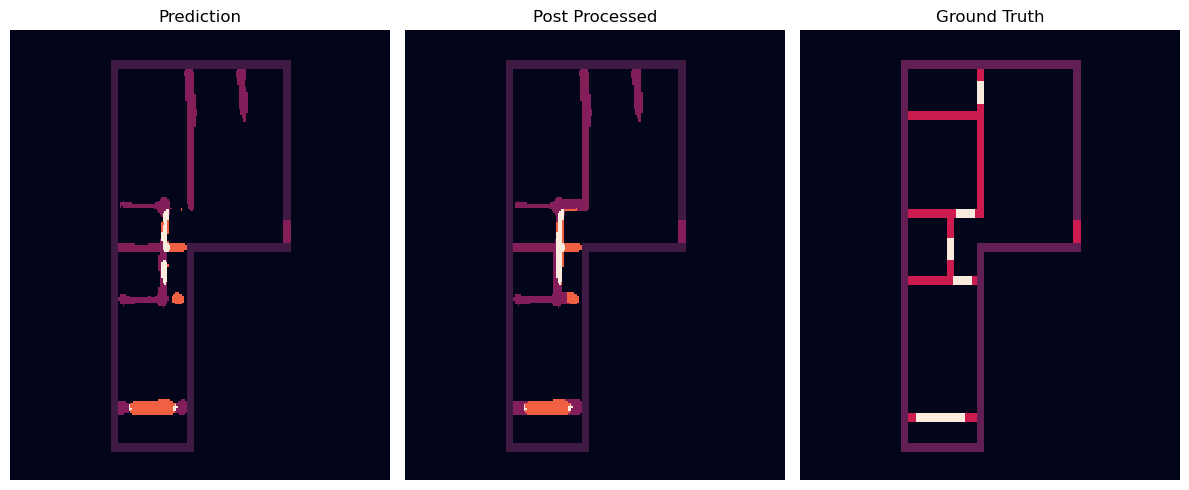

In [184]:
input_arrs = np.sum([boundary_mask_gt, room_mask_gt*2, door_mask_gt*4], axis=0)

pred_room_bin = np.where(pred_room >= 0.20, 1, 0)
pred_door_bin = np.where(pred_door >= 0.15, 1, 0)

stacked_layers = np.sum([pred_room_bin*2, pred_door_bin*4], axis=0)
img = stacked_layers.copy().astype(np.uint8)

dilate_kernel = np.ones((5,5), np.uint8)
img = cv.dilate(img, dilate_kernel, iterations = 1)

close_kernel = np.ones((5,5), np.uint8)
img = cv.morphologyEx(img, cv.MORPH_CLOSE, close_kernel, iterations=2)

erode_kernel = np.ones((5,5), np.uint8)
img = cv.erode(img, erode_kernel, iterations = 1)

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

sns.heatmap(np.sum([boundary_mask_gt, stacked_layers], axis=0), ax=ax[0], 
            cbar=False, xticklabels=False, yticklabels=False)
ax[0].set_title("Prediction")

sns.heatmap(np.sum([boundary_mask_gt, img], axis=0), ax=ax[1], 
            cbar=False, xticklabels=False, yticklabels=False)
ax[1].set_title("Post Processed")

sns.heatmap(input_arrs, 
            cbar=False, xticklabels=False, yticklabels=False)
ax[2].set_title("Ground Truth")

plt.tight_layout()
plt.show()